In [6]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Set plot style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Define paths (Relative to 'analysis' folder)
data_dir = os.path.join("..", "Data")
pkl_path = os.path.join(data_dir, "liesel_output_camera.pkl")

print(f"Looking for data at: {os.path.abspath(pkl_path)}")

Looking for data at: c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\PackageComparison\Data\liesel_output_camera.pkl


In [8]:
# Load the pickle file
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        saved_data = pickle.load(f)
    
    print("File loaded successfully.")
    
    # Extract samples
    samples = saved_data["samples"]
    
    # Check shape
    # Liesel output is typically (Chains, Draws, Units, Params)
    print(f"Beta shape (Chains, Draws, Units, Params): {samples['beta_i'].shape}")
    
else:
    print("Error: Pickle file not found. Make sure you ran the training script first.")

File loaded successfully.
Beta shape (Chains, Draws, Units, Params): (4, 2000, 332, 10)


In [9]:
# 1. Flatten Chains and Draws
# ---------------------------
# We combine chains (4) and draws (2000) into a single dimension -> (8000, Units, Params)
beta_raw = samples['beta_i']
n_chains, n_draws, n_units, n_params = beta_raw.shape
beta_flat = beta_raw.reshape(n_chains * n_draws, n_units, n_params)

print(f"Reshaped for analysis: {beta_flat.shape}")

# 2. Select First Customer (Index 0)
# ----------------------------------
unit_idx = 0
customer_betas = beta_flat[:, unit_idx, :] # Shape: (8000, 10)

# 3. Create DataFrame
# -------------------
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]
df_cust = pd.DataFrame(customer_betas, columns=param_names)

# Melt for Seaborn
df_melted = df_cust.melt(var_name="Parameter", value_name="Utility")

print(f"Data ready for Customer #{unit_idx + 1}")

Reshaped for analysis: (8000, 332, 10)
Data ready for Customer #1


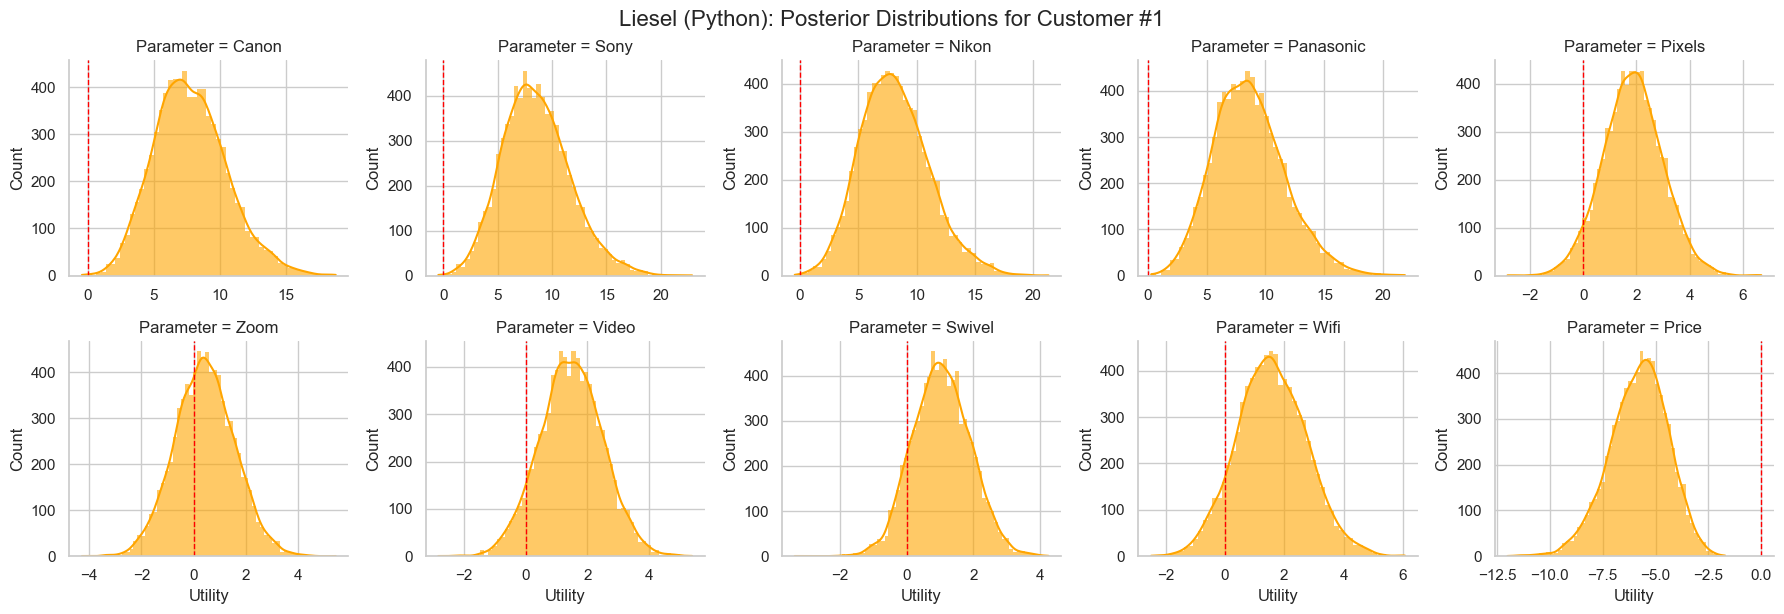

In [10]:
# Plot Distributions (Facet Grid)
g = sns.FacetGrid(
    df_melted, 
    col="Parameter", 
    col_wrap=5,      # 5 plots per row
    sharex=False,    # Let x-axis scales vary per parameter
    sharey=False,    # Let y-axis scales vary (density height)
    height=3, 
    aspect=1.2
)

# Add Histograms with KDE (Kernel Density Estimate)
# Using orange to distinguish from R plots (usually blue/teal)
g.map(sns.histplot, "Utility", kde=True, color="orange", alpha=0.6, linewidth=0)

# Add a reference line at 0 (Neutral Preference)
g.map(plt.axvline, x=0, color='red', linestyle='--', linewidth=1)

# Titles
g.fig.suptitle(f"Liesel (Python): Posterior Distributions for Customer #{unit_idx+1}", y=1.02, fontsize=16)

plt.show()